In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")


In [8]:
TRAIN_PATH = "../data/processed/train.csv"

df = pd.read_csv(TRAIN_PATH)

print("Shape:", df.shape)
df.head()


Shape: (175, 26)


,nta2020,ntaname,num_bbls,avg_unitsres,avg_unitstotal,avg_yearbuilt,avg_market_value,num_properties,school_count,avg_ats,murder,rape,robbery,felony_assault,burglary,grand_larceny,grand_larceny_auto,total_violations,buildings_with_violations,violations_per_building,rent_impairing_violations,pct_rent_impairing,rent_num_properties,avg_monthly_rent,median_monthly_rent,log_median_rent
0,QN0601,Rego Park,2583,5.470770,5.953930,1906.347658,7.774261e+05,4704.243264,NaN,NaN,0.225370,3.490564,20.929933,34.290739,32.218593,89.470923,34.229803,10802.0,323.0,33.4427,610.0,0.0565,28.0,1902.657064,1869.060588,7.533191
1,BK1204,Mapleton-Midwood (West),5143,2.547540,2.723702,1904.803228,8.090730e+05,6279.703180,NaN,NaN,0.976761,4.217520,32.988229,64.446533,41.426248,147.547358,66.761663,26663.0,933.0,28.5777,1366.0,0.0512,13.0,3324.565056,2444.750000,7.801698
2,BX0702,Bedford Park,1309,17.839572,18.310924,1835.779985,1.097847e+06,1385.907912,NaN,NaN,2.108588,11.711685,117.391944,206.040030,55.494601,238.921371,89.940230,143154.0,847.0,169.0130,9345.0,0.0653,6.0,1946.530777,1529.090556,7.332428
3,BX1102,Morris Park,4000,2.291000,2.455250,1861.246750,4.909766e+05,7701.209734,NaN,NaN,0.526091,8.943540,65.761321,136.783547,53.661238,200.703551,123.105193,15883.0,736.0,21.5802,737.0,0.0464,1.0,1562.361111,1562.361111,7.353953
4,QN0703,Bay Terrace-Clearview,2644,4.157716,4.257943,1920.768154,6.930299e+05,3669.665040,NaN,NaN,0.601232,4.790118,27.470490,53.722316,57.924764,123.242515,64.531534,2275.0,175.0,13.0000,32.0,0.0141,1.0,1455.052083,1455.052083,7.282797


In [20]:
TARGET = "log_median_rent"

EXCLUDE_COLS = [
    "nta2020",
    "ntaname",
    "median_monthly_rent",
    "avg_monthly_rent",
    "rent_num_properties",
    TARGET
]

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[feature_cols]
y = df[TARGET]

print("Number of features:", len(feature_cols))


Number of features: 20


In [21]:
# Force everything to numeric (non-numeric becomes NaN)
X = X.apply(pd.to_numeric, errors="coerce")

# Drop columns that are entirely NaN (can’t be learned from)
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

# Update feature_cols to match the actual X used
feature_cols = X.columns.tolist()
print("Final feature count:", len(feature_cols))


Dropping all-NaN columns: ['school_count', 'avg_ats']
Final feature count: 18


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
ridge_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fills NaNs per-column
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge RMSE (log):", ridge_rmse)
print("Ridge MAE (log):", ridge_mae)


Ridge RMSE (log): 0.32144270414265935
Ridge MAE (log): 0.25328374694510963


In [25]:
rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE (log):", rf_rmse)
print("Random Forest MAE (log):", rf_mae)


Random Forest RMSE (log): 0.24763005539328306
Random Forest MAE (log): 0.18443644279726534


In [26]:
ridge_mae_dollars = np.mean(np.abs(np.exp(y_test) - np.exp(y_pred_ridge)))
rf_mae_dollars = np.mean(np.abs(np.exp(y_test) - np.exp(y_pred_rf)))

print("Ridge MAE ($):", ridge_mae_dollars)
print("Random Forest MAE ($):", rf_mae_dollars)


Ridge MAE ($): 844.6249881190191
Random Forest MAE ($): 455.68545601150703


In [27]:
rf_model = rf_pipe.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15)


pct_rent_impairing           0.304260
grand_larceny                0.128589
avg_market_value             0.091181
violations_per_building      0.072340
grand_larceny_auto           0.051123
buildings_with_violations    0.045564
murder                       0.037379
num_properties               0.033030
avg_yearbuilt                0.031358
avg_unitstotal               0.030081
rent_impairing_violations    0.028232
avg_unitsres                 0.027607
total_violations             0.024617
burglary                     0.023088
rape                         0.020853
dtype: float64

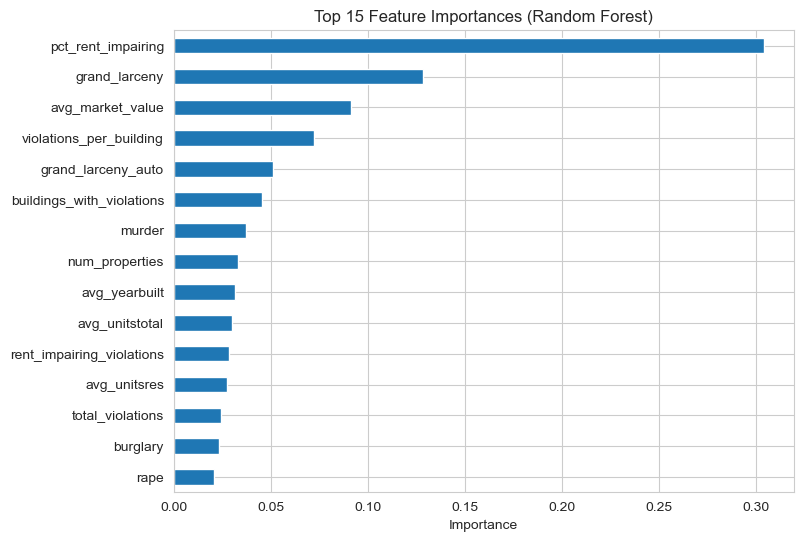

In [28]:
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()


In [29]:
X = X.apply(pd.to_numeric, errors="coerce")
